# **GAME SALES ANALYTICS**
### Do desempenho comercial aos padrões que ajudam a explicá-lo

Nem todo jogo bem avaliado vende muito. Nem todo sucesso comercial recebe as melhores notas. Este projeto investiga **quais características disponíveis de um jogo estão associadas às vendas globais**, usando `Global_Sales` como alvo contínuo.

A análise segue o **CRISP-DM** e combina Business Analytics com modelos estritamente pertencentes à família da regressão linear. O objetivo não é prometer uma previsão absoluta de sucesso, mas construir um instrumento reproduzível de **explicação e benchmarking pós-lançamento**.

> **Pergunta central:** até que ponto as características do produto e os sinais de recepção disponíveis ajudam a explicar suas vendas globais — e o que os erros revelam sobre o que a base não captura?

**Alunos:** Gabriel Silveira e Marcos Reis  
**Dataset:** [Video Game Sales with Ratings](https://www.kaggle.com/datasets/rush4ratio/video-game-sales-with-ratings)  
**Alvo:** `Global_Sales`, em milhões de unidades.

## 1) Business Understanding

### Objetivo

Entender quais características estão associadas ao desempenho comercial global e produzir referências úteis para comparação de portfólio, gênero e plataforma.

### Critérios de sucesso

- comparar todos os modelos pela mesma validação cruzada;
- usar **RMSE como métrica principal**, por penalizar mais fortemente erros grandes;
- usar MAE e R² como métricas complementares;
- avaliar o teste reservado somente depois da seleção;
- manter a modelagem dentro da regressão linear, incluindo regularização e transformações justificadas.

### Limite de interpretação

Notas, contagens de avaliações e desenvolvedora podem ser conhecidas apenas após o lançamento. Portanto, o resultado será interpretado como análise explicativa e benchmarking pós-lançamento, e não como previsão pré-lançamento ou relação causal.

## 2) Data Understanding

### 2.1 Imports e configurações

In [1]:
# Manipulação e visualização dos dados
import json
import warnings
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from IPython.display import display
from kagglehub import KaggleDatasetAdapter

# Preparação, modelagem e validação
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda valor: f"{valor:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

SEMENTE = 42
ALVO = "Global_Sales"

C:\Users\gabri\Desktop\games-analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.2 Carregamento reproduzível

O arquivo é obtido pelo KaggleHub. A leitura explicita a codificação porque o conjunto contém caracteres incompatíveis com UTF-8 em algumas linhas. Nenhuma linha é descartada silenciosamente.

In [2]:
caminho_arquivo = "Video_Games_Sales_as_at_22_Dec_2016.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "rush4ratio/video-game-sales-with-ratings",
    caminho_arquivo,
    pandas_kwargs={"encoding": "cp1252", "encoding_errors": "replace"},
)

print(f"Dimensão da base: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
display(df.head(3))

Dimensão da base: 16,719 linhas × 16 colunas


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,"2,006.000",Sports,Nintendo,41.360,28.960,3.770,8.450,82.530,76.000,51.000,8,322.000,Nintendo,E
1,Super Mario Bros.,NES,"1,985.000",Platform,Nintendo,29.080,3.580,6.810,0.770,40.240,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,"2,008.000",Racing,Nintendo,15.680,12.760,3.790,3.290,35.520,82.000,73.000,8.3,709.000,Nintendo,E


### 2.3 Auditoria estrutural

A auditoria verifica tipos, ausências, cardinalidade e duplicatas exatas antes de qualquer transformação. Isso separa problemas reais de qualidade de dados de escolhas posteriores de modelagem.

In [3]:
def resumir_estrutura(dados):
    # Retorna tipo, preenchimento e cardinalidade de cada coluna.
    return pd.DataFrame({
        "tipo": dados.dtypes.astype(str),
        "não_nulos": dados.notna().sum(),
        "ausentes": dados.isna().sum(),
        "ausentes_%": dados.isna().mean().mul(100).round(2),
        "valores_únicos": dados.nunique(dropna=True),
    })


estrutura = resumir_estrutura(df)
display(estrutura)
print(f"Duplicatas exatas: {df.duplicated().sum():,}")
display(df.describe(include="number").T)

,tipo,não_nulos,ausentes,ausentes_%,valores_únicos
Name,str,16717,2,0.010,11562
Platform,str,16719,0,0.000,31
Year_of_Release,float64,16450,269,1.610,39
Genre,str,16717,2,0.010,12
Publisher,str,16665,54,0.320,581
NA_Sales,float64,16719,0,0.000,402
EU_Sales,float64,16719,0,0.000,307
JP_Sales,float64,16719,0,0.000,244
Other_Sales,float64,16719,0,0.000,155
Global_Sales,float64,16719,0,0.000,629


Duplicatas exatas: 0


,count,mean,std,min,25%,50%,75%,max
Year_of_Release,"16,450.000","2,006.487",5.879,"1,980.000","2,003.000","2,007.000","2,010.000","2,020.000"
NA_Sales,"16,719.000",0.263,0.814,0.000,0.000,0.080,0.240,41.360
EU_Sales,"16,719.000",0.145,0.503,0.000,0.000,0.020,0.110,28.960
JP_Sales,"16,719.000",0.078,0.309,0.000,0.000,0.000,0.040,10.220
Other_Sales,"16,719.000",0.047,0.187,0.000,0.000,0.010,0.030,10.570
Global_Sales,"16,719.000",0.534,1.548,0.010,0.060,0.170,0.470,82.530
Critic_Score,"8,137.000",68.968,13.938,13.000,60.000,71.000,79.000,98.000
Critic_Count,"8,137.000",26.361,18.980,3.000,12.000,21.000,36.000,113.000
User_Count,"7,590.000",162.230,561.282,4.000,10.000,24.000,81.000,"10,665.000"


> **Decisão:** não eliminar linhas por duplicidade nesta etapa. A base não contém duplicatas integrais; combinações iguais de nome e plataforma serão apenas investigadas, pois podem representar anos, versões ou registros diferentes.

### 2.4 Valores ausentes e o marcador `tbd`

Registros com User_Score = 'tbd': 2,425


,ausentes,percentual_%
User_Count,9129,54.600
Critic_Count,8582,51.330
Critic_Score,8582,51.330
Rating,6769,40.490
User_Score,6704,40.100
Developer,6623,39.610
Year_of_Release,269,1.610
Publisher,54,0.320
Name,2,0.010
Genre,2,0.010


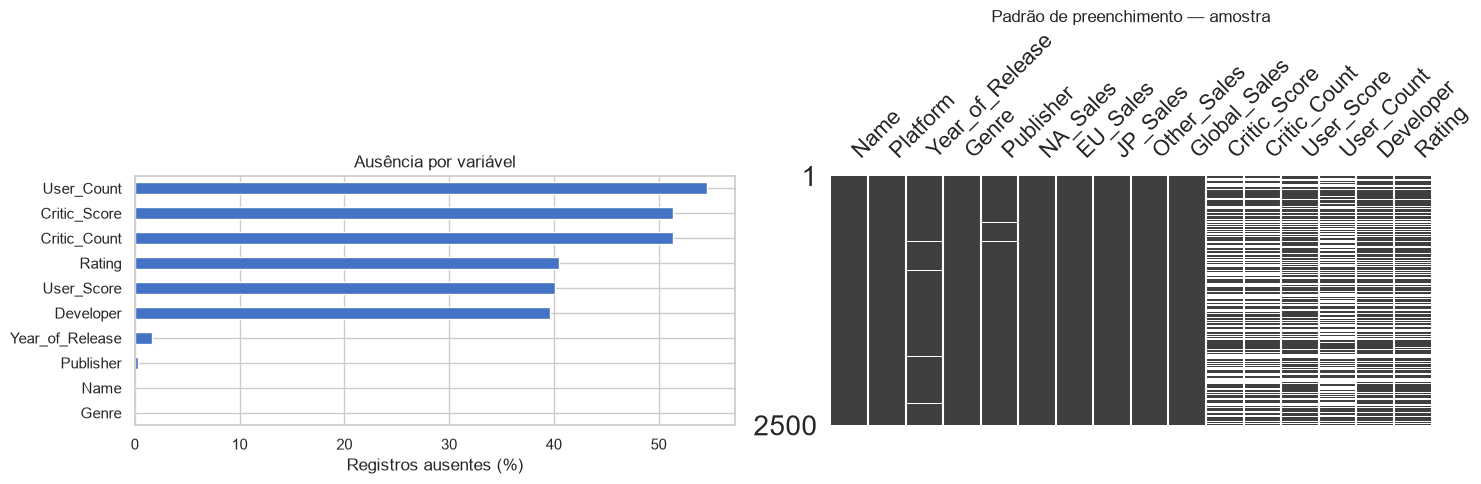

In [4]:
nulos = pd.DataFrame({
    "ausentes": df.isna().sum(),
    "percentual_%": df.isna().mean().mul(100).round(2),
}).sort_values("percentual_%", ascending=False)

quantidade_tbd = df["User_Score"].eq("tbd").sum()
print(f"Registros com User_Score = 'tbd': {quantidade_tbd:,}")
display(nulos)

fig, eixos = plt.subplots(1, 2, figsize=(15, 5))
nulos.query("ausentes > 0")["percentual_%"].sort_values().plot.barh(ax=eixos[0], color="#4472C4")
eixos[0].set(title="Ausência por variável", xlabel="Registros ausentes (%)", ylabel="")

msno.matrix(df.sample(min(2_500, len(df)), random_state=SEMENTE), ax=eixos[1], sparkline=False)
eixos[1].set_title("Padrão de preenchimento — amostra")
plt.tight_layout()
plt.show()

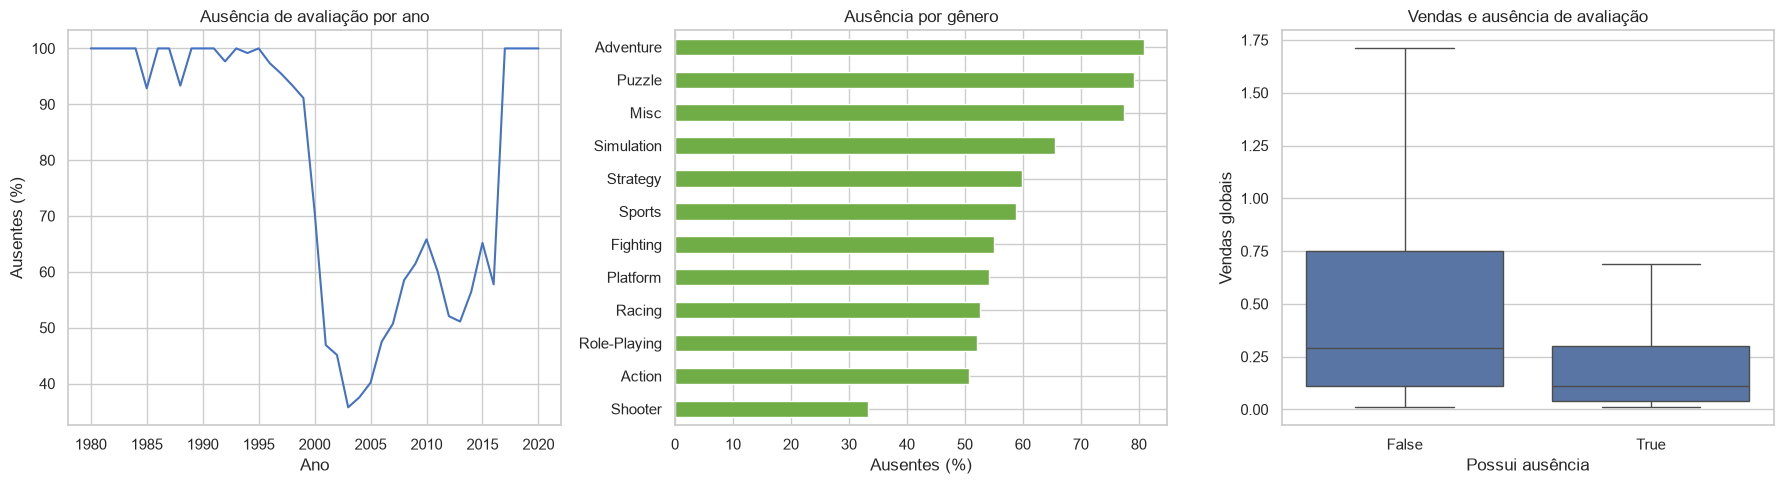

,count,median,mean
possui_ausência,,,
False,6947,0.290,0.773
True,9772,0.110,0.363


In [5]:
# "tbd" significa que a avaliação ainda não foi determinada; não é uma nota.
eda = df.copy()
eda["User_Score"] = pd.to_numeric(eda["User_Score"].replace("tbd", np.nan), errors="coerce")

colunas_avaliacao = [
    "Critic_Score", "Critic_Count", "User_Score",
    "User_Count", "Developer", "Rating",
]
eda["Tem_Ausente_Avaliacao"] = eda[colunas_avaliacao].isna().any(axis=1)

ausencia_por_ano = (
    eda.dropna(subset=["Year_of_Release"])
       .groupby("Year_of_Release")["Tem_Ausente_Avaliacao"]
       .mean().mul(100)
)
ausencia_por_genero = (
    eda.groupby("Genre")["Tem_Ausente_Avaliacao"]
       .mean().mul(100).sort_values()
)

fig, eixos = plt.subplots(1, 3, figsize=(18, 5))
eixos[0].plot(ausencia_por_ano.index, ausencia_por_ano.values, color="#4472C4")
eixos[0].set(title="Ausência de avaliação por ano", xlabel="Ano", ylabel="Ausentes (%)")
ausencia_por_genero.plot.barh(ax=eixos[1], color="#70AD47")
eixos[1].set(title="Ausência por gênero", xlabel="Ausentes (%)", ylabel="")
sns.boxplot(data=eda, x="Tem_Ausente_Avaliacao", y=ALVO, showfliers=False, ax=eixos[2])
eixos[2].set(title="Vendas e ausência de avaliação", xlabel="Possui ausência", ylabel="Vendas globais")
plt.tight_layout()
plt.show()

display(
    eda.groupby("Tem_Ausente_Avaliacao")[ALVO]
       .agg(["count", "median", "mean"])
       .rename_axis("possui_ausência")
)

> **Decisão:** converter `tbd` em ausência e preservar os registros incompletos. A ausência varia com ano, gênero e nível de vendas, portanto remover todas as linhas incompletas alteraria a composição da amostra. A imputação será feita dentro do pipeline e ajustada apenas no treino; indicadores de ausência permitirão ao modelo representar parte desse padrão.

### 2.5 Duplicatas semânticas

In [6]:
mesmo_jogo_plataforma = (
    df[df["Name"].notna() & df.duplicated(["Name", "Platform"], keep=False)]
      .sort_values(["Name", "Platform", "Year_of_Release"])
)

print(f"Registros em combinações repetidas de jogo-plataforma: {len(mesmo_jogo_plataforma)}")
display(mesmo_jogo_plataforma)

Registros em combinações repetidas de jogo-plataforma: 8


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
604,Madden NFL 13,PS3,"2,012.000",Sports,Electronic Arts,2.110,0.220,0.000,0.230,2.560,83.000,22.000,5.5,101.000,EA Tiburon,E
16233,Madden NFL 13,PS3,"2,012.000",Sports,Electronic Arts,0.000,0.010,0.000,0.000,0.010,83.000,22.000,5.5,101.000,EA Tiburon,E
5973,Need for Speed: Most Wanted,PC,"2,005.000",Racing,Electronic Arts,0.020,0.230,0.000,0.040,0.290,82.000,19.000,8.5,525.000,Black Box,T
11716,Need for Speed: Most Wanted,PC,"2,012.000",Racing,Electronic Arts,0.000,0.060,0.000,0.020,0.080,82.000,19.000,8.5,525.000,Black Box,T
1591,Need for Speed: Most Wanted,X360,"2,005.000",Racing,Electronic Arts,1.000,0.130,0.020,0.100,1.250,83.000,54.000,8.5,134.000,EA Canada,T
1190,Need for Speed: Most Wanted,X360,"2,012.000",Racing,Electronic Arts,0.620,0.780,0.010,0.150,1.560,83.000,54.000,8.5,134.000,EA Canada,T
1745,Sonic the Hedgehog,PS3,"2,006.000",Platform,Sega,0.410,0.060,0.040,0.660,1.160,43.000,17.000,4.1,176.000,Sonic Team,E10+
4127,Sonic the Hedgehog,PS3,NaN,Platform,NaN,0.000,0.480,0.000,0.000,0.480,43.000,17.000,4.1,176.000,Sonic Team,E10+


> **Decisão:** manter essas observações. Repetição da chave simplificada não comprova duplicação integral, e os demais atributos podem registrar lançamentos ou avaliações distintos. Excluir sem uma regra de negócio confirmada destruiria informação legítima.

### 2.6 Distribuição do alvo e presença de blockbusters

,Global_Sales
0.000,0.010
0.250,0.060
0.500,0.170
0.750,0.470
0.900,1.200
0.950,2.040
0.990,5.458
1.000,82.530


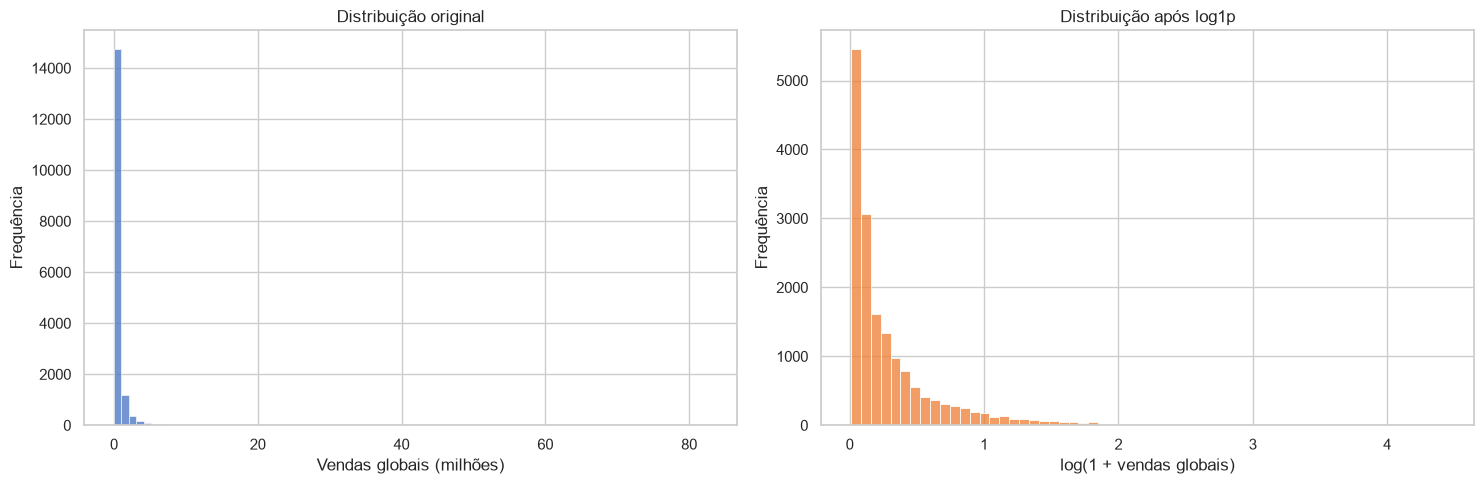

Assimetria original: 17.38
Assimetria após log1p: 2.76


In [7]:
quantis_alvo = eda[ALVO].quantile([0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1]).to_frame("Global_Sales")
display(quantis_alvo)

fig, eixos = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(eda[ALVO], bins=80, ax=eixos[0], color="#4472C4")
eixos[0].set(title="Distribuição original", xlabel="Vendas globais (milhões)", ylabel="Frequência")
sns.histplot(np.log1p(eda[ALVO]), bins=60, ax=eixos[1], color="#ED7D31")
eixos[1].set(title="Distribuição após log1p", xlabel="log(1 + vendas globais)", ylabel="Frequência")
plt.tight_layout()
plt.show()

print(f"Assimetria original: {eda[ALVO].skew():.2f}")
print(f"Assimetria após log1p: {np.log1p(eda[ALVO]).skew():.2f}")

#### Leitura visual da cauda de vendas

O histograma mostra a concentração, mas pode esconder a cauda. A distribuição acumulada indica qual parcela dos jogos permanece abaixo de cada nível de vendas, enquanto o boxplot em escala logarítmica mantém os blockbusters visíveis sem comprimir toda a base.

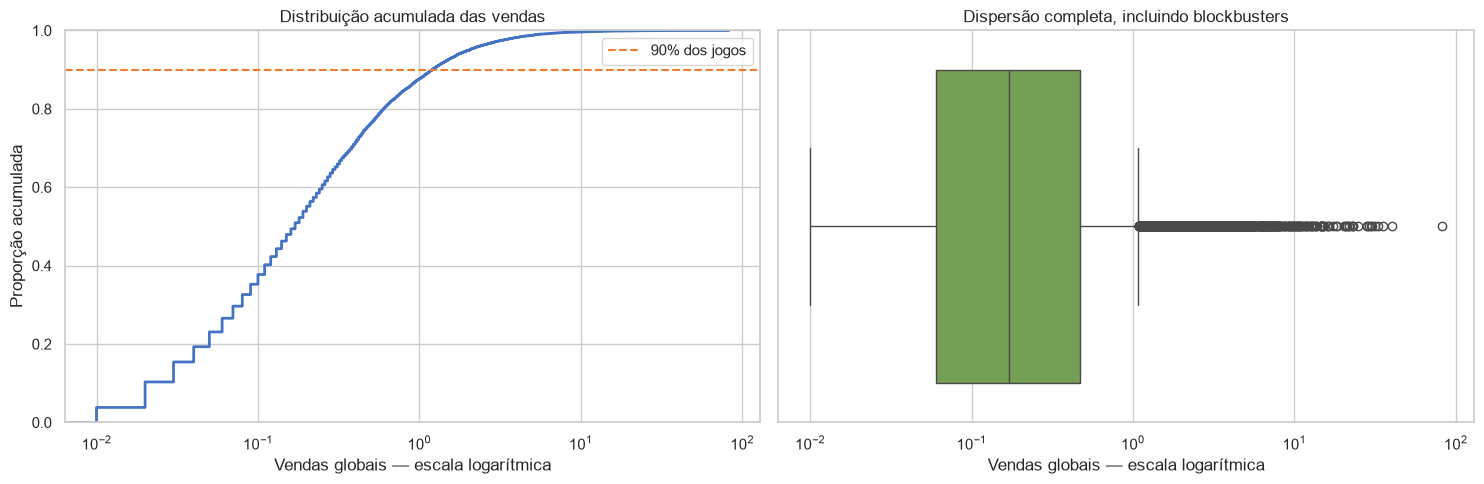

In [8]:
fig, eixos = plt.subplots(1, 2, figsize=(15, 5))

sns.ecdfplot(data=eda, x=ALVO, ax=eixos[0], color="#4472C4", linewidth=2)
eixos[0].set_xscale("log")
eixos[0].axhline(0.90, color="#ED7D31", linestyle="--", label="90% dos jogos")
eixos[0].set(
    title="Distribuição acumulada das vendas",
    xlabel="Vendas globais — escala logarítmica",
    ylabel="Proporção acumulada",
)
eixos[0].legend()

sns.boxplot(x=eda[ALVO], ax=eixos[1], color="#70AD47")
eixos[1].set_xscale("log")
eixos[1].set(title="Dispersão completa, incluindo blockbusters", xlabel="Vendas globais — escala logarítmica")

plt.tight_layout()
plt.show()

> **Decisão:** manter os blockbusters. Eles são observações reais e comercialmente importantes, não erros de coleta. A assimetria justifica testar transformações logarítmicas e analisar erros por faixa, mas não autoriza remover sucessos extremos para melhorar artificialmente as métricas.

### 2.7 Relações com o alvo

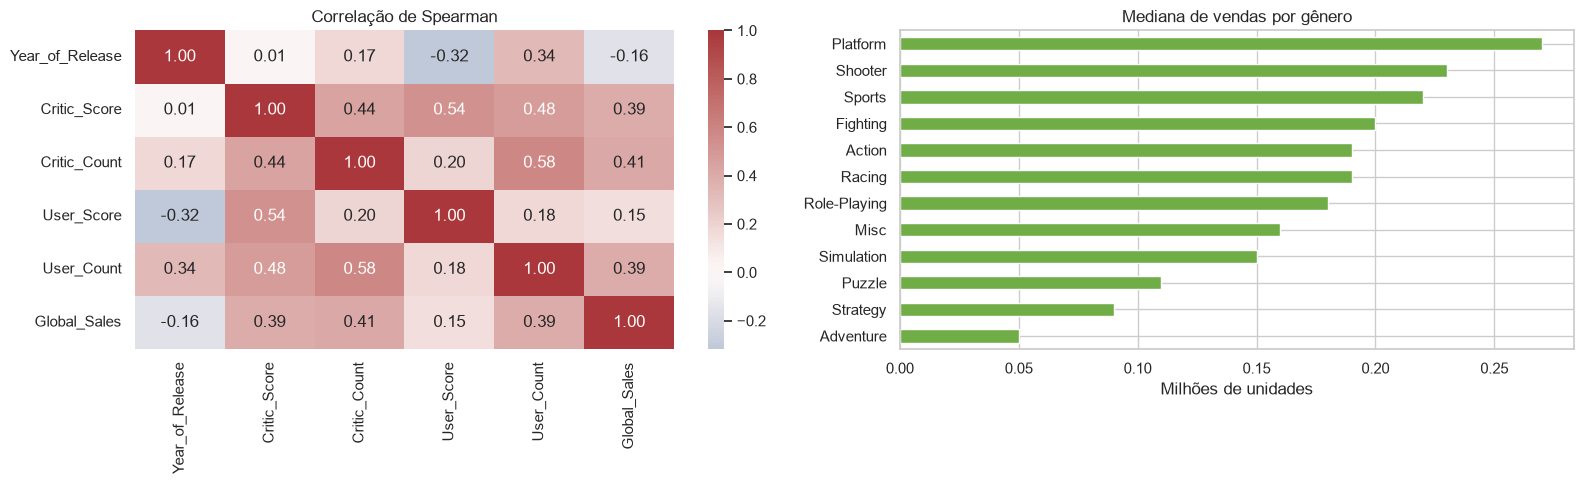

,Global_Sales
Global_Sales,1.000
Critic_Count,0.408
Critic_Score,0.394
User_Count,0.393
User_Score,0.150
Year_of_Release,-0.161


,median,mean,count
Genre,,,
Platform,0.270,0.933,888
Shooter,0.230,0.796,1323
Sports,0.220,0.567,2348
Fighting,0.200,0.527,849
Racing,0.190,0.584,1249
Action,0.190,0.518,3370
Role-Playing,0.180,0.623,1500
Misc,0.160,0.459,1750
Simulation,0.150,0.447,874


In [9]:
numericas_analise = [
    "Year_of_Release", "Critic_Score", "Critic_Count",
    "User_Score", "User_Count", ALVO,
]
correlacoes = eda[numericas_analise].corr(method="spearman")

fig, eixos = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(correlacoes, annot=True, fmt=".2f", cmap="vlag", center=0, ax=eixos[0])
eixos[0].set_title("Correlação de Spearman")

generos = eda.groupby("Genre")[ALVO].agg(["median", "mean", "count"]).sort_values("median")
generos["median"].plot.barh(ax=eixos[1], color="#70AD47")
eixos[1].set(title="Mediana de vendas por gênero", xlabel="Milhões de unidades", ylabel="")
plt.tight_layout()
plt.show()

display(correlacoes[[ALVO]].sort_values(ALVO, ascending=False))
display(generos.sort_values("median", ascending=False))

#### Como cobertura e avaliações se relacionam com vendas?

Os gráficos usam transparência, amostragem reproduzível e escala logarítmica no alvo. O objetivo é tornar visíveis tanto a concentração de jogos de baixa venda quanto a tendência geral, sem sugerir que correlação implica causalidade.

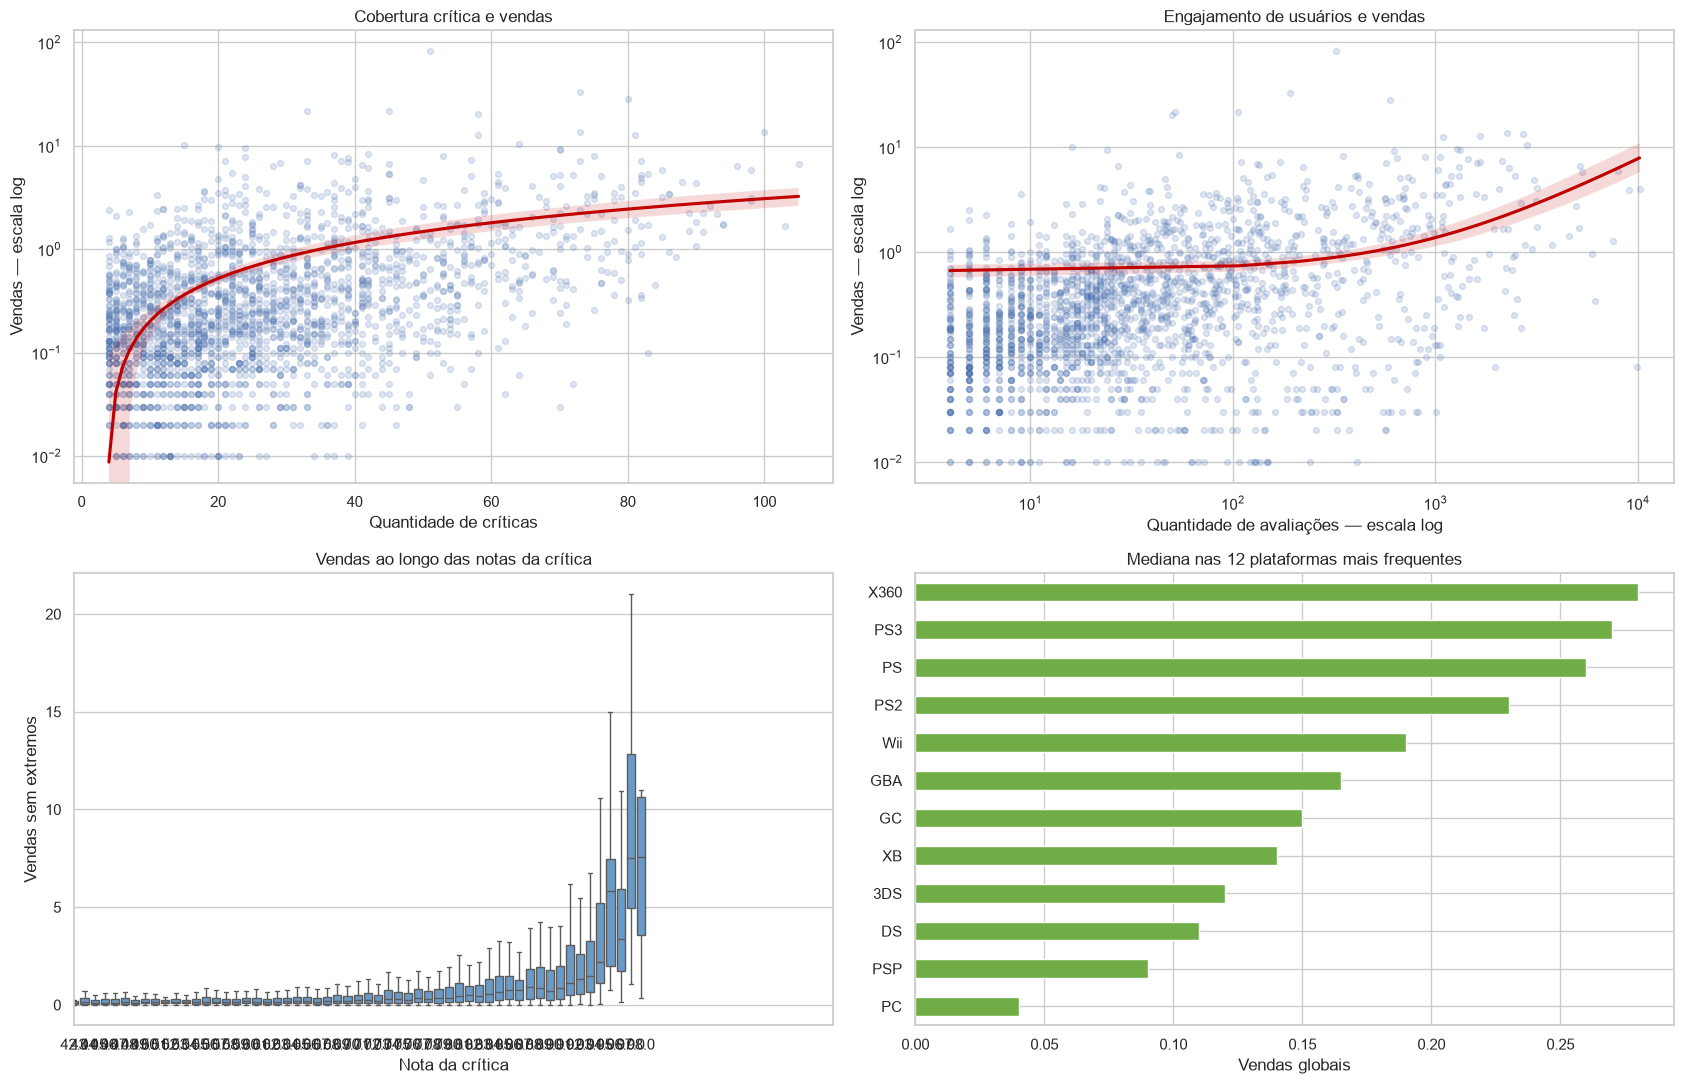

In [10]:
amostra_relacoes = eda.sample(min(5_000, len(eda)), random_state=SEMENTE)
plataformas_principais = eda["Platform"].value_counts().head(12).index
resumo_plataformas = (
    eda[eda["Platform"].isin(plataformas_principais)]
    .groupby("Platform")[ALVO]
    .agg(["median", "mean", "count"])
    .sort_values("median")
)

fig, eixos = plt.subplots(2, 2, figsize=(17, 11))
sns.regplot(
    data=amostra_relacoes, x="Critic_Count", y=ALVO,
    scatter_kws={"alpha": 0.18, "s": 18}, line_kws={"color": "#C00000"},
    ax=eixos[0, 0],
)
eixos[0, 0].set_yscale("log")
eixos[0, 0].set(title="Cobertura crítica e vendas", xlabel="Quantidade de críticas", ylabel="Vendas — escala log")

sns.regplot(
    data=amostra_relacoes, x="User_Count", y=ALVO,
    scatter_kws={"alpha": 0.18, "s": 18}, line_kws={"color": "#C00000"},
    ax=eixos[0, 1],
)
eixos[0, 1].set(xscale="log", yscale="log", title="Engajamento de usuários e vendas", xlabel="Quantidade de avaliações — escala log", ylabel="Vendas — escala log")

sns.boxplot(data=eda, x="Critic_Score", y=ALVO, showfliers=False, ax=eixos[1, 0], color="#5B9BD5")
eixos[1, 0].set_xlim(25, 100)
eixos[1, 0].set(title="Vendas ao longo das notas da crítica", xlabel="Nota da crítica", ylabel="Vendas sem extremos")

resumo_plataformas["median"].plot.barh(ax=eixos[1, 1], color="#70AD47")
eixos[1, 1].set(title="Mediana nas 12 plataformas mais frequentes", xlabel="Vendas globais", ylabel="")

plt.tight_layout()
plt.show()

> **Decisão:** `Critic_Count` será usada na regressão simples porque apresenta associação relevante com o alvo e uma interpretação clara como intensidade de cobertura crítica. A regressão múltipla acrescentará notas, engajamento, ano e categorias para verificar se oferecem informação incremental. Associação não será descrita como causalidade.

## 3) Data Preparation

### 3.1 Seleção e engenharia de atributos

As vendas regionais são componentes diretos de `Global_Sales`; utilizá-las faria o modelo reconstruir contabilmente o alvo, e não aprender associações generalizáveis. `Name` também é excluído por ser um identificador de alta cardinalidade. As transformações logarítmicas abaixo são determinísticas e não aprendem estatísticas da amostra.

In [11]:
VENDAS_REGIONAIS = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
NUMERICAS_BASE = ["Year_of_Release", "Critic_Score", "Critic_Count", "User_Score", "User_Count"]
CATEGORICAS_BASE = ["Platform", "Genre", "Rating"]
CATEGORICAS_ESTENDIDAS = CATEGORICAS_BASE + ["Publisher", "Developer"]

dados_modelo = df.copy()
dados_modelo["User_Score"] = pd.to_numeric(
    dados_modelo["User_Score"].replace("tbd", np.nan), errors="coerce"
)

# Logaritmos reduzem a influência de contagens extremamente assimétricas.
dados_modelo["Log_Critic_Count"] = np.log1p(dados_modelo["Critic_Count"])
dados_modelo["Log_User_Count"] = np.log1p(dados_modelo["User_Count"])

# Termos não lineares continuam formando uma regressão linear nos coeficientes.
dados_modelo["Critic_Score_Quadrado"] = dados_modelo["Critic_Score"] ** 2
dados_modelo["User_Score_Quadrado"] = dados_modelo["User_Score"] ** 2
dados_modelo["Interacao_Critica_Usuario"] = (
    dados_modelo["Critic_Score"] * dados_modelo["User_Score"]
)

NUMERICAS_LOG = [
    "Year_of_Release", "Critic_Score", "Log_Critic_Count",
    "User_Score", "Log_User_Count",
]
NUMERICAS_EXPANDIDAS = NUMERICAS_LOG + [
    "Critic_Score_Quadrado", "User_Score_Quadrado", "Interacao_Critica_Usuario",
]

assert not set(VENDAS_REGIONAIS).intersection(NUMERICAS_EXPANDIDAS + CATEGORICAS_ESTENDIDAS)
assert "Name" not in NUMERICAS_EXPANDIDAS + CATEGORICAS_ESTENDIDAS

print("Variáveis regionais excluídas:", VENDAS_REGIONAIS)
print("Identificador excluído: Name")

Variáveis regionais excluídas: ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
Identificador excluído: Name


### 3.2 Separação treino-teste antes do pré-processamento

In [12]:
# O teste fica isolado até a escolha do modelo. Todas as comparações usam apenas o treino.
indices_treino, indices_teste = train_test_split(
    dados_modelo.index,
    test_size=0.20,
    random_state=SEMENTE,
)

treino = dados_modelo.loc[indices_treino].copy()
teste = dados_modelo.loc[indices_teste].copy()
y_treino = treino[ALVO]
y_teste = teste[ALVO]

print(f"Treino: {len(treino):,} registros ({len(treino) / len(dados_modelo):.0%})")
print(f"Teste reservado: {len(teste):,} registros ({len(teste) / len(dados_modelo):.0%})")

Treino: 13,375 registros (80%)
Teste reservado: 3,344 registros (20%)


### 3.3 Pipelines sem vazamento

In [13]:
def criar_preprocessador(numericas, categoricas):
    # Cria imputação, escala e codificação ajustadas somente dentro de cada treino.
    pipeline_numerico = Pipeline([
        ("imputacao", SimpleImputer(strategy="median", add_indicator=True)),
        ("escala", StandardScaler()),
    ])
    pipeline_categorico = Pipeline([
        ("imputacao", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
    ])
    return ColumnTransformer([
        ("numericas", pipeline_numerico, numericas),
        ("categoricas", pipeline_categorico, categoricas),
    ])


def criar_pipeline(regressor, numericas, categoricas):
    # Une pré-processamento e regressão em um único objeto validável.
    return Pipeline([
        ("preprocessamento", criar_preprocessador(numericas, categoricas)),
        ("regressao", regressor),
    ])


cv = KFold(n_splits=5, shuffle=True, random_state=SEMENTE)
metricas_cv = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

> **Decisão:** imputação, escala, agrupamento de categorias raras e codificação permanecem dentro do pipeline. Assim, cada dobra da validação aprende esses parâmetros apenas com sua porção de treino. Categorias novas são ignoradas de forma segura, e `Publisher`/`Developer` não geram uma coluna para cada ocorrência rara.

## 4) Modeling

### 4.1 Estratégia de comparação

O baseline mede o ganho mínimo necessário. Depois são avaliadas regressão simples, múltipla, inclusão de categorias de alta cardinalidade controlada, transformações logarítmicas, Ridge e termos de interação. Todas continuam sendo regressões lineares nos parâmetros.

In [14]:
modelos = {}

modelos["Baseline — mediana"] = Pipeline([
    ("imputacao", SimpleImputer(strategy="median")),
    ("regressao", DummyRegressor(strategy="median")),
])

modelos["Linear simples — Critic_Count"] = Pipeline([
    ("imputacao", SimpleImputer(strategy="median", add_indicator=True)),
    ("regressao", LinearRegression()),
])

modelos["Linear múltipla — base"] = criar_pipeline(
    LinearRegression(), NUMERICAS_BASE, CATEGORICAS_BASE
)
modelos["Linear múltipla — Publisher/Developer"] = criar_pipeline(
    LinearRegression(), NUMERICAS_BASE, CATEGORICAS_ESTENDIDAS
)
modelos["Linear múltipla — contagens em log"] = criar_pipeline(
    LinearRegression(), NUMERICAS_LOG, CATEGORICAS_ESTENDIDAS
)

pipeline_alvo_log = criar_pipeline(
    Ridge(alpha=1.0), NUMERICAS_LOG, CATEGORICAS_ESTENDIDAS
)
modelos["Linear — alvo em log"] = TransformedTargetRegressor(
    regressor=pipeline_alvo_log,
    func=np.log1p,
    inverse_func=np.expm1,
)

### 4.2 Regularização Ridge e otimização de hiperparâmetro

In [15]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1_000.0]

busca_ridge = GridSearchCV(
    estimator=criar_pipeline(Ridge(), NUMERICAS_LOG, CATEGORICAS_ESTENDIDAS),
    param_grid={"regressao__alpha": alphas},
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=1,
)
busca_ridge.fit(treino[NUMERICAS_LOG + CATEGORICAS_ESTENDIDAS], y_treino)
melhor_alpha_ridge = busca_ridge.best_params_["regressao__alpha"]
modelos[f"Ridge — alpha={melhor_alpha_ridge:g}"] = criar_pipeline(
    Ridge(alpha=melhor_alpha_ridge), NUMERICAS_LOG, CATEGORICAS_ESTENDIDAS
)

busca_expandida = GridSearchCV(
    estimator=criar_pipeline(Ridge(), NUMERICAS_EXPANDIDAS, CATEGORICAS_ESTENDIDAS),
    param_grid={"regressao__alpha": alphas},
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=1,
)
busca_expandida.fit(treino[NUMERICAS_EXPANDIDAS + CATEGORICAS_ESTENDIDAS], y_treino)
melhor_alpha_expandido = busca_expandida.best_params_["regressao__alpha"]
modelos[f"Ridge — termos expandidos, alpha={melhor_alpha_expandido:g}"] = criar_pipeline(
    Ridge(alpha=melhor_alpha_expandido), NUMERICAS_EXPANDIDAS, CATEGORICAS_ESTENDIDAS
)

print(f"Melhor alpha do Ridge com contagens em log: {melhor_alpha_ridge:g}")
print(f"Melhor alpha do Ridge com termos expandidos: {melhor_alpha_expandido:g}")

Melhor alpha do Ridge com contagens em log: 10
Melhor alpha do Ridge com termos expandidos: 10


> **Justificativa:** Ridge não muda a natureza linear do modelo; apenas penaliza coeficientes excessivos. Isso é especialmente útil após one-hot encoding e criação de termos correlacionados. O valor de `alpha` não é escolhido por conveniência, mas pela menor média de RMSE na validação cruzada.

### 4.3 Comparação pela mesma validação cruzada

In [16]:
def colunas_do_modelo(nome):
    # Retorna exatamente as colunas exigidas por cada candidato.
    if nome == "Baseline — mediana" or nome == "Linear simples — Critic_Count":
        return ["Critic_Count"]
    if nome == "Linear múltipla — base":
        return NUMERICAS_BASE + CATEGORICAS_BASE
    if nome == "Linear múltipla — Publisher/Developer":
        return NUMERICAS_BASE + CATEGORICAS_ESTENDIDAS
    if "termos expandidos" in nome:
        return NUMERICAS_EXPANDIDAS + CATEGORICAS_ESTENDIDAS
    return NUMERICAS_LOG + CATEGORICAS_ESTENDIDAS


resultados = []
for nome, modelo in modelos.items():
    colunas = colunas_do_modelo(nome)
    pontuacoes = cross_validate(
        modelo,
        treino[colunas],
        y_treino,
        scoring=metricas_cv,
        cv=cv,
        n_jobs=1,
        return_train_score=True,
    )
    resultados.append({
        "modelo": nome,
        "RMSE_cv": -pontuacoes["test_RMSE"].mean(),
        "RMSE_cv_dp": pontuacoes["test_RMSE"].std(),
        "RMSE_treino": -pontuacoes["train_RMSE"].mean(),
        "MAE_cv": -pontuacoes["test_MAE"].mean(),
        "R2_cv": pontuacoes["test_R2"].mean(),
    })

comparacao_modelos = pd.DataFrame(resultados).sort_values("RMSE_cv").reset_index(drop=True)
display(comparacao_modelos.round(4))

,modelo,RMSE_cv,RMSE_cv_dp,RMSE_treino,MAE_cv,R2_cv
0,"Ridge — termos expandidos, alpha=10",1.200,0.065,1.187,0.493,0.265
1,Ridge — alpha=10,1.206,0.062,1.193,0.497,0.257
2,Linear múltipla — contagens em log,1.207,0.061,1.192,0.500,0.257
3,Linear múltipla — Publisher/Developer,1.212,0.069,1.193,0.487,0.251
4,Linear — alvo em log,1.213,0.061,1.206,0.388,0.249
5,Linear múltipla — base,1.266,0.069,1.255,0.503,0.183
6,Linear simples — Critic_Count,1.343,0.066,1.345,0.529,0.079
7,Baseline — mediana,1.444,0.060,1.445,0.457,-0.065


#### Ganho e estabilidade dos modelos

As barras com intervalo mostram a média do RMSE entre as cinco dobras e um desvio-padrão. O segundo painel compara treino e validação: uma distância grande seria evidência de sobreajuste.

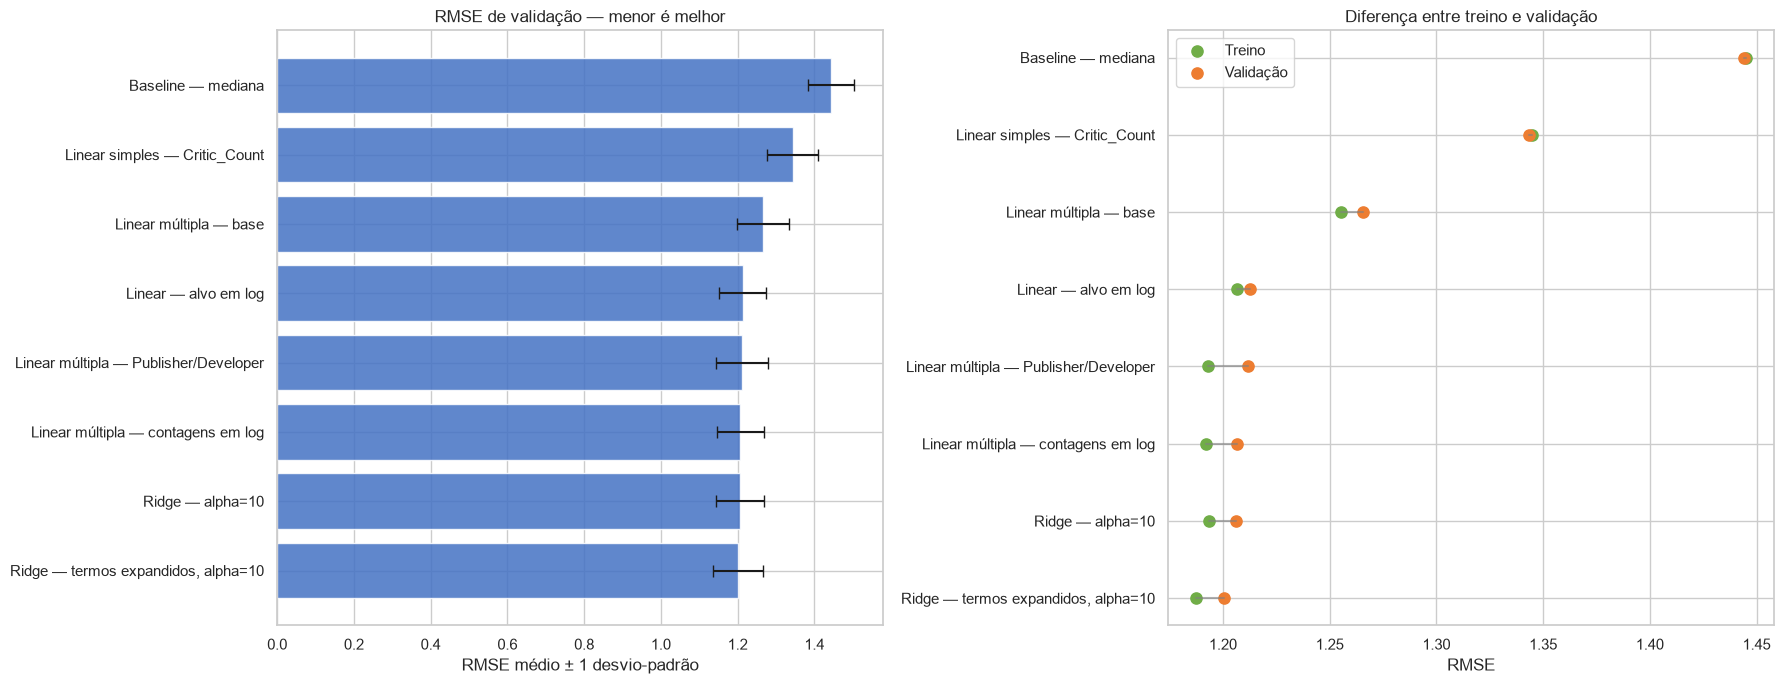

In [17]:
ordem_grafico = comparacao_modelos.sort_values("RMSE_cv", ascending=True)

fig, eixos = plt.subplots(1, 2, figsize=(18, 7))
eixos[0].barh(
    ordem_grafico["modelo"], ordem_grafico["RMSE_cv"],
    xerr=ordem_grafico["RMSE_cv_dp"], color="#4472C4", alpha=0.85, capsize=4,
)
eixos[0].set(title="RMSE de validação — menor é melhor", xlabel="RMSE médio ± 1 desvio-padrão", ylabel="")

posicoes = np.arange(len(ordem_grafico))
eixos[1].scatter(ordem_grafico["RMSE_treino"], posicoes, label="Treino", color="#70AD47", s=65)
eixos[1].scatter(ordem_grafico["RMSE_cv"], posicoes, label="Validação", color="#ED7D31", s=65)
for posicao, (_, linha) in zip(posicoes, ordem_grafico.iterrows()):
    eixos[1].plot([linha["RMSE_treino"], linha["RMSE_cv"]], [posicao, posicao], color="gray", alpha=0.6)
eixos[1].set_yticks(posicoes, ordem_grafico["modelo"])
eixos[1].set(title="Diferença entre treino e validação", xlabel="RMSE", ylabel="")
eixos[1].legend()

plt.tight_layout()
plt.show()

In [18]:
melhor_nome = comparacao_modelos.loc[0, "modelo"]
segundo_rmse = comparacao_modelos.loc[1, "RMSE_cv"]
melhor_rmse = comparacao_modelos.loc[0, "RMSE_cv"]
ganho_relativo = (segundo_rmse - melhor_rmse) / segundo_rmse

# Um ganho inferior a 0,5% não compensa termos expandidos se houver alternativa mais simples.
if "termos expandidos" in melhor_nome and ganho_relativo < 0.005:
    candidatos_simples = comparacao_modelos[~comparacao_modelos["modelo"].str.contains("termos expandidos")]
    melhor_nome = candidatos_simples.iloc[0]["modelo"]
    criterio_complexidade = "termos expandidos rejeitados: ganho inferior a 0,5%"
else:
    criterio_complexidade = "melhor RMSE mantido; ganho justificou a complexidade"

modelo_final = clone(modelos[melhor_nome])
colunas_finais = colunas_do_modelo(melhor_nome)

print(f"Modelo selecionado: {melhor_nome}")
print(f"Critério de parcimônia: {criterio_complexidade}")

Modelo selecionado: Ridge — alpha=10
Critério de parcimônia: termos expandidos rejeitados: ganho inferior a 0,5%


> **Decisão:** o modelo é selecionado pelo menor RMSE médio de validação. A dispersão entre dobras e a diferença treino-validação são consideradas para identificar instabilidade. Termos expandidos só são aceitos quando entregam ganho material, evitando complexidade sem benefício prático.

## 5) Evaluation

### 5.1 Avaliação única no teste reservado

Somente após a seleção, o pipeline escolhido é ajustado em todo o conjunto de treino e aplicado ao teste. Também mostramos o pós-processamento que limita previsões a zero: ele respeita o domínio físico das vendas, mas não esconde a quantidade de valores negativos produzidos originalmente.

In [19]:
modelo_final.fit(treino[colunas_finais], y_treino)
previsao_bruta = modelo_final.predict(teste[colunas_finais])
previsao_nao_negativa = np.clip(previsao_bruta, 0, None)

def calcular_metricas(y_real, y_previsto):
    # Calcula as três métricas adotadas no projeto.
    return {
        "RMSE": mean_squared_error(y_real, y_previsto) ** 0.5,
        "MAE": mean_absolute_error(y_real, y_previsto),
        "R2": r2_score(y_real, y_previsto),
    }


metricas_teste = pd.DataFrame([
    {"previsão": "bruta", **calcular_metricas(y_teste, previsao_bruta)},
    {"previsão": "limitada a zero", **calcular_metricas(y_teste, previsao_nao_negativa)},
])

quantidade_negativas = int((previsao_bruta < 0).sum())
percentual_negativas = quantidade_negativas / len(previsao_bruta) * 100

print(f"Modelo final: {melhor_nome}")
print(f"Previsões negativas antes do corte: {quantidade_negativas:,} ({percentual_negativas:.2f}%)")
display(metricas_teste.round(4))

Modelo final: Ridge — alpha=10
Previsões negativas antes do corte: 506 (15.13%)


,previsão,RMSE,MAE,R2
0,bruta,1.807,0.527,0.209
1,limitada a zero,1.801,0.494,0.214


#### Onde a previsão acompanha os valores reais?

A escala logarítmica permite avaliar a região em que está a maioria dos jogos. A curva por decis mostra se o modelo acompanha o nível médio de vendas ou comprime excessivamente os extremos.

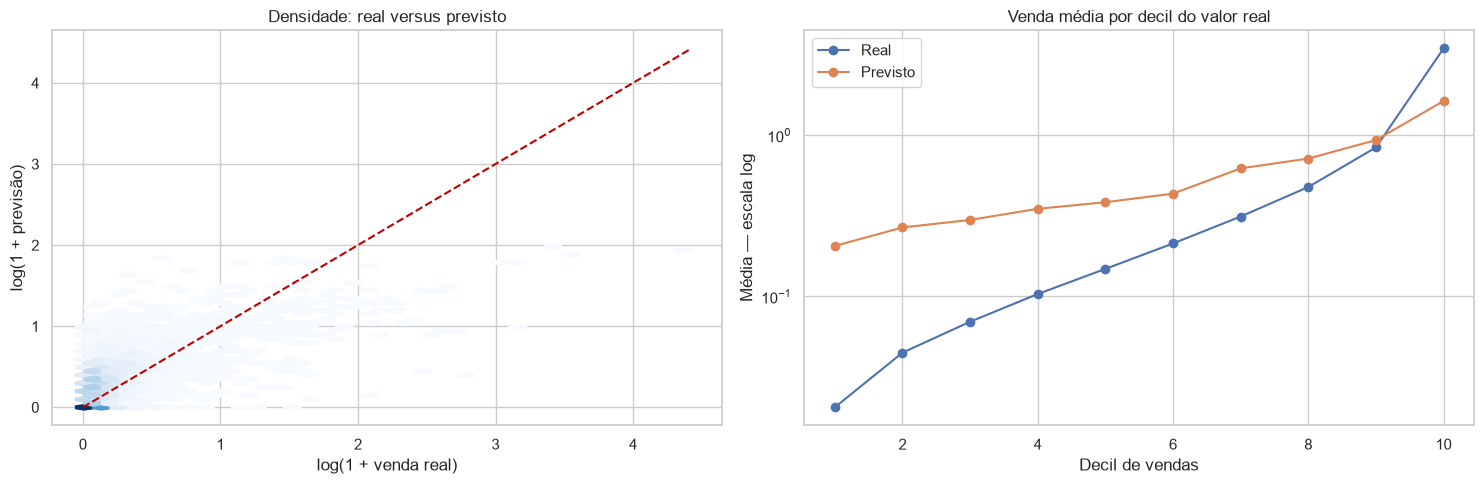

In [20]:
comparacao_decis = pd.DataFrame({"real": y_teste, "previsto": previsao_nao_negativa})
comparacao_decis["decil_real"] = pd.qcut(comparacao_decis["real"], 10, duplicates="drop")
resumo_decis = comparacao_decis.groupby("decil_real", observed=True).agg(
    venda_real=("real", "mean"),
    venda_prevista=("previsto", "mean"),
    registros=("real", "size"),
).reset_index(drop=True)

fig, eixos = plt.subplots(1, 2, figsize=(15, 5))
eixos[0].hexbin(
    np.log1p(y_teste), np.log1p(previsao_nao_negativa),
    gridsize=35, mincnt=1, cmap="Blues",
)
limite_log = max(np.log1p(y_teste).max(), np.log1p(previsao_nao_negativa).max())
eixos[0].plot([0, limite_log], [0, limite_log], "--", color="#C00000")
eixos[0].set(title="Densidade: real versus previsto", xlabel="log(1 + venda real)", ylabel="log(1 + previsão)")

eixos[1].plot(resumo_decis.index + 1, resumo_decis["venda_real"], marker="o", label="Real")
eixos[1].plot(resumo_decis.index + 1, resumo_decis["venda_prevista"], marker="o", label="Previsto")
eixos[1].set_yscale("log")
eixos[1].set(title="Venda média por decil do valor real", xlabel="Decil de vendas", ylabel="Média — escala log")
eixos[1].legend()

plt.tight_layout()
plt.show()

### 5.2 Diagnóstico dos resíduos e dos maiores erros

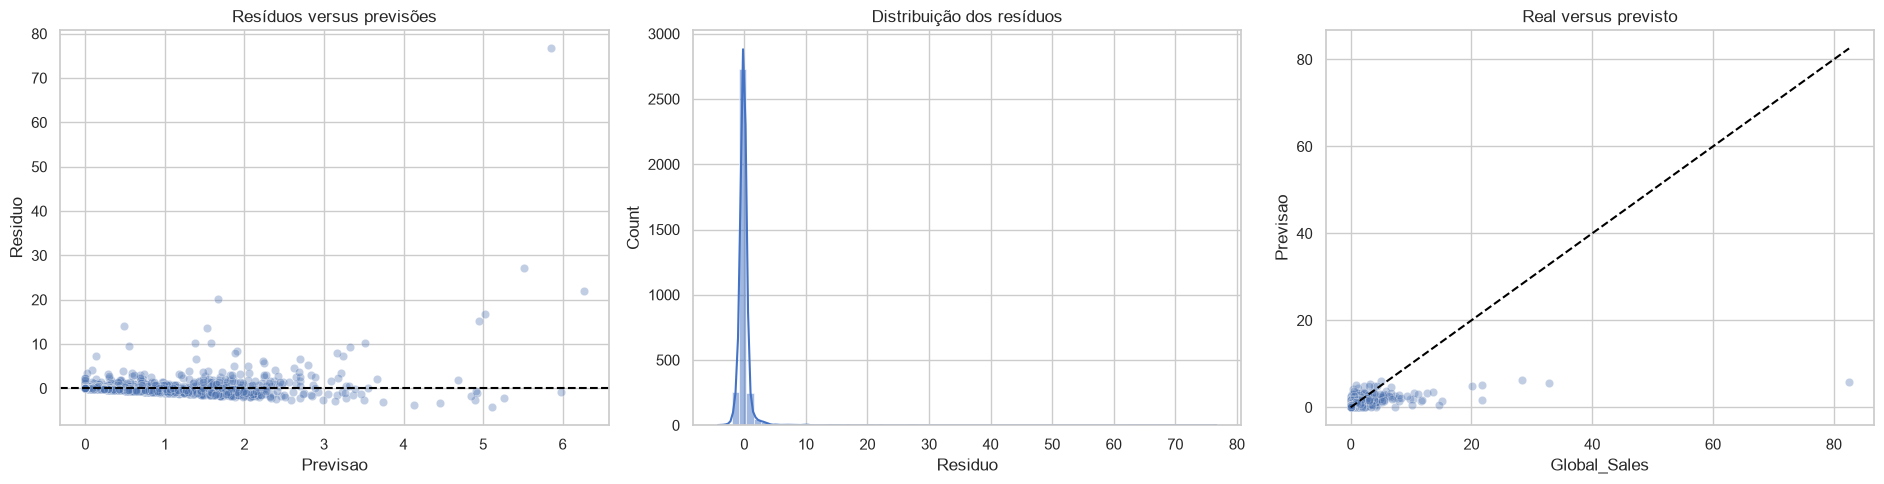

,Name,Platform,Genre,Global_Sales,Previsao,Residuo,Erro_Absoluto
0,Wii Sports,Wii,Sports,82.530,5.852,76.678,76.678
3,Wii Sports Resort,Wii,Sports,32.770,5.509,27.261,27.261
8,New Super Mario Bros. Wii,Wii,Platform,28.320,6.266,22.054,22.054
14,Kinect Adventures!,X360,Misc,21.810,1.665,20.145,20.145
15,Wii Fit Plus,Wii,Sports,21.790,5.027,16.763,16.763
19,Brain Age: Train Your Brain in Minutes a Day,DS,Misc,20.150,4.947,15.203,15.203
31,Call of Duty: Black Ops 3,PS4,Shooter,14.630,0.491,14.139,14.139
27,Pokemon Black/Pokemon White,DS,Role-Playing,15.140,1.535,13.605,13.605
47,Pokemon Omega Ruby/Pokemon Alpha Sapphire,3DS,Role-Playing,11.680,1.382,10.298,10.298
46,Pokemon HeartGold/Pokemon SoulSilver,DS,Action,11.770,1.577,10.193,10.193


In [21]:
avaliacao = teste[["Name", "Platform", "Genre", ALVO]].copy()
avaliacao["Previsao"] = previsao_nao_negativa
avaliacao["Residuo"] = avaliacao[ALVO] - avaliacao["Previsao"]
avaliacao["Erro_Absoluto"] = avaliacao["Residuo"].abs()
avaliacao["Faixa_Vendas"] = pd.cut(
    avaliacao[ALVO],
    bins=[-np.inf, 0.1, 0.5, 1, 5, np.inf],
    labels=["Até 0,1", "0,1–0,5", "0,5–1", "1–5", "Acima de 5"],
)

fig, eixos = plt.subplots(1, 3, figsize=(19, 5))
sns.scatterplot(data=avaliacao, x="Previsao", y="Residuo", alpha=0.35, ax=eixos[0])
eixos[0].axhline(0, color="black", linestyle="--")
eixos[0].set_title("Resíduos versus previsões")
sns.histplot(avaliacao["Residuo"], bins=70, kde=True, ax=eixos[1], color="#4472C4")
eixos[1].set_title("Distribuição dos resíduos")
sns.scatterplot(data=avaliacao, x=ALVO, y="Previsao", alpha=0.35, ax=eixos[2])
limite = max(avaliacao[ALVO].max(), avaliacao["Previsao"].max())
eixos[2].plot([0, limite], [0, limite], "--", color="black")
eixos[2].set_title("Real versus previsto")
plt.tight_layout()
plt.show()

display(
    avaliacao.nlargest(10, "Erro_Absoluto")
    [["Name", "Platform", "Genre", ALVO, "Previsao", "Residuo", "Erro_Absoluto"]]
)

### 5.3 Erro por faixa, gênero e plataforma

In [22]:
def resumo_por_grupo(dados, coluna, minimo=20):
    # Resume erro por segmento e omite grupos pequenos e instáveis.
    resumo = dados.groupby(coluna, observed=True).agg(
        registros=(ALVO, "size"),
        venda_media=(ALVO, "mean"),
        MAE=("Erro_Absoluto", "mean"),
        vies=("Residuo", "mean"),
    )
    return resumo.query("registros >= @minimo").sort_values("MAE", ascending=False)


print("Desempenho por faixa de vendas")
display(resumo_por_grupo(avaliacao, "Faixa_Vendas", minimo=1))
print("Desempenho por gênero")
display(resumo_por_grupo(avaliacao, "Genre"))
print("Desempenho nas plataformas com pelo menos 20 registros de teste")
display(resumo_por_grupo(avaliacao, "Platform"))

Desempenho por faixa de vendas


,registros,venda_media,MAE,vies
Faixa_Vendas,,,,
Acima de 5,46,11.332,8.682,8.643
1–5,351,2.010,0.925,0.602
"0,5–1",371,0.713,0.429,-0.132
"0,1–0,5",1354,0.251,0.342,-0.249
"Até 0,1",1222,0.050,0.249,-0.219


Desempenho por gênero


,registros,venda_media,MAE,vies
Genre,,,,
Shooter,258,0.853,0.735,-0.057
Platform,170,0.851,0.715,-0.085
Sports,465,0.752,0.595,0.195
Role-Playing,306,0.633,0.573,-0.041
Misc,324,0.565,0.513,0.075
Racing,243,0.555,0.469,-0.045
Puzzle,116,0.411,0.462,-0.219
Simulation,199,0.418,0.427,-0.064
Action,703,0.506,0.407,-0.050


Desempenho nas plataformas com pelo menos 20 registros de teste


,registros,venda_media,MAE,vies
Platform,,,,
Wii,268,1.081,0.969,0.422
WiiU,26,0.621,0.692,-0.510
PS4,82,0.778,0.643,-0.064
SNES,55,0.544,0.637,-0.409
PC,176,0.388,0.633,-0.255
X360,252,0.773,0.607,0.015
N64,75,0.686,0.545,0.037
2600,25,0.597,0.479,-0.249
GBA,164,0.377,0.479,-0.128


#### Mapa de erro por gênero e faixa de vendas

O mapa cruza duas dimensões que isoladamente podem esconder problemas. Células vazias ou com menos de cinco jogos são omitidas para evitar conclusões baseadas em amostras frágeis.

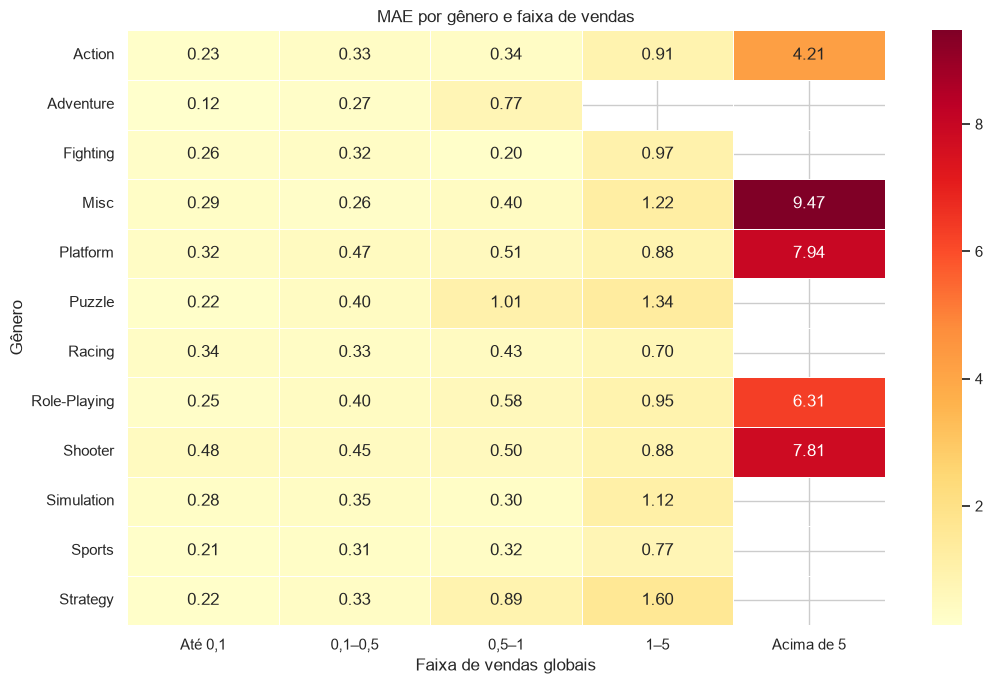

In [23]:
erro_cruzado = (
    avaliacao.groupby(["Genre", "Faixa_Vendas"], observed=True)
    .agg(MAE=("Erro_Absoluto", "mean"), registros=(ALVO, "size"))
    .reset_index()
)
erro_cruzado.loc[erro_cruzado["registros"] < 5, "MAE"] = np.nan
mapa_erro = erro_cruzado.pivot(index="Genre", columns="Faixa_Vendas", values="MAE")

plt.figure(figsize=(11, 7))
sns.heatmap(mapa_erro, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("MAE por gênero e faixa de vendas")
plt.xlabel("Faixa de vendas globais")
plt.ylabel("Gênero")
plt.tight_layout()
plt.show()

> **Interpretação esperada:** em uma distribuição tão assimétrica, poucos blockbusters dominam o RMSE e tendem a ser subestimados. O MAE por faixa e o viés mostram onde o modelo é útil para benchmarking típico e onde faltam variáveis explicativas.

### 5.4 Multicolinearidade e interpretação dos coeficientes

In [24]:
def calcular_vif(dados, colunas):
    # Calcula VIF sem dependência externa, após imputação mediana.
    matriz = SimpleImputer(strategy="median").fit_transform(dados[colunas])
    valores = []
    for indice, coluna in enumerate(colunas):
        y_coluna = matriz[:, indice]
        outras = np.delete(matriz, indice, axis=1)
        r2_auxiliar = LinearRegression().fit(outras, y_coluna).score(outras, y_coluna)
        vif = np.inf if r2_auxiliar >= 0.999999 else 1 / (1 - r2_auxiliar)
        valores.append({"variável": coluna, "VIF": vif})
    return pd.DataFrame(valores).sort_values("VIF", ascending=False)


display(calcular_vif(treino, NUMERICAS_BASE))

# TransformedTargetRegressor guarda o pipeline ajustado em regressor_.
pipeline_ajustado = modelo_final.regressor_ if isinstance(modelo_final, TransformedTargetRegressor) else modelo_final
preprocessador_ajustado = pipeline_ajustado.named_steps.get("preprocessamento")
regressor_ajustado = pipeline_ajustado.named_steps["regressao"]

if preprocessador_ajustado is not None and hasattr(regressor_ajustado, "coef_"):
    nomes_atributos = preprocessador_ajustado.get_feature_names_out()
    coeficientes = pd.DataFrame({
        "atributo": nomes_atributos,
        "coeficiente": np.ravel(regressor_ajustado.coef_),
    })
    coeficientes["magnitude"] = coeficientes["coeficiente"].abs()
    display(coeficientes.nlargest(15, "magnitude")[["atributo", "coeficiente"]])
else:
    print("O baseline não possui coeficientes interpretáveis.")

,variável,VIF
1,Critic_Score,1.556
3,User_Score,1.359
2,Critic_Count,1.357
4,User_Count,1.231
0,Year_of_Release,1.056


,atributo,coeficiente
172,categoricas__Developer_Nintendo,2.576
101,categoricas__Publisher_Nintendo,1.255
14,categoricas__Platform_GB,1.113
19,categoricas__Platform_NES,0.926
20,categoricas__Platform_PC,-0.799
137,categoricas__Developer_BioWare,-0.655
190,categoricas__Developer_Treyarch,0.653
30,categoricas__Platform_WiiU,-0.500
97,categoricas__Publisher_Microsoft Game Studios,0.489
4,numericas__Log_User_Count,0.463


> **Decisão de interpretação:** VIF elevado sinaliza redundância entre preditores, não invalida automaticamente o modelo preditivo. Quando selecionado, Ridge reduz a sensibilidade dos coeficientes. Coeficientes indicam associação condicional dentro desta amostra; categorias, escalas e possível transformação do alvo precisam ser consideradas antes de atribuir significado substantivo.

### 5.5 OLS como diagnóstico estatístico complementar

`LinearRegression` já estima mínimos quadrados ordinários, mas não fornece diretamente testes de hipótese e intervalos. Para verificar se uma leitura inferencial é defensável, ajustamos um OLS reduzido no **treino**, com alvo em `log1p`, atributos numéricos e dummies de gênero, plataforma e classificação.

Como a base é heterogênea e assimétrica, são usados erros-padrão robustos HC3. Breusch–Pagan, Jarque–Bera, gráfico Q–Q e resíduos versus ajustados verificam os pressupostos. O OLS será tratado como ferramenta explicativa complementar, não como substituto automático do Ridge selecionado por validação.

In [25]:
COLUNAS_OLS_NUMERICAS = [
    "Year_of_Release", "Critic_Score", "Log_Critic_Count",
    "User_Score", "Log_User_Count",
]
COLUNAS_OLS_CATEGORICAS = ["Genre", "Platform", "Rating"]


def preparar_matriz_ols(dados, parametros=None, colunas_referencia=None):
    # Imputa e padroniza com estatísticas aprendidas somente no treino.
    numericas = dados[COLUNAS_OLS_NUMERICAS].copy()
    if parametros is None:
        medianas = numericas.median()
        preenchidas = numericas.fillna(medianas)
        medias = preenchidas.mean()
        desvios = preenchidas.std().replace(0, 1)
        parametros = {"medianas": medianas, "medias": medias, "desvios": desvios}
    numericas = numericas.fillna(parametros["medianas"])
    numericas = (numericas - parametros["medias"]) / parametros["desvios"]
    categoricas = pd.get_dummies(
        dados[COLUNAS_OLS_CATEGORICAS].fillna("Ausente"),
        prefix=COLUNAS_OLS_CATEGORICAS,
        drop_first=True,
        dtype=float,
    )
    matriz = pd.concat([numericas, categoricas], axis=1).astype(float)
    matriz = sm.add_constant(matriz, has_constant="add")
    if colunas_referencia is not None:
        matriz = matriz.reindex(columns=colunas_referencia, fill_value=0.0)
    return matriz, parametros


X_ols_treino, parametros_ols = preparar_matriz_ols(treino)
y_ols_treino = np.log1p(y_treino)
modelo_ols = sm.OLS(y_ols_treino, X_ols_treino).fit(cov_type="HC3")

estatistica_bp, pvalor_bp, _, _ = het_breuschpagan(modelo_ols.resid, modelo_ols.model.exog)
estatistica_jb, pvalor_jb = stats.jarque_bera(modelo_ols.resid)

tabela_ols = pd.DataFrame({
    "coeficiente": modelo_ols.params,
    "erro_padrao_HC3": modelo_ols.bse,
    "p_valor": modelo_ols.pvalues,
    "IC_2,5%": modelo_ols.conf_int()[0],
    "IC_97,5%": modelo_ols.conf_int()[1],
})

print(f"R² ajustado no alvo log: {modelo_ols.rsquared_adj:.4f}")
print(f"Breusch–Pagan — p-valor: {pvalor_bp:.3e}")
print(f"Jarque–Bera — p-valor: {pvalor_jb:.3e}")
print(f"Número de condição: {modelo_ols.condition_number:,.1f}")
display(tabela_ols.loc[COLUNAS_OLS_NUMERICAS].round(4))

R² ajustado no alvo log: 0.3388
Breusch–Pagan — p-valor: 1.500e-148
Jarque–Bera — p-valor: 0.000e+00
Número de condição: 171.8


,coeficiente,erro_padrao_HC3,p_valor,"IC_2,5%","IC_97,5%"
Year_of_Release,-0.108,0.009,0.000,-0.127,-0.090
Critic_Score,0.070,0.004,0.000,0.063,0.077
Log_Critic_Count,0.024,0.004,0.000,0.017,0.031
User_Score,-0.032,0.003,0.000,-0.038,-0.025
Log_User_Count,0.158,0.005,0.000,0.147,0.169


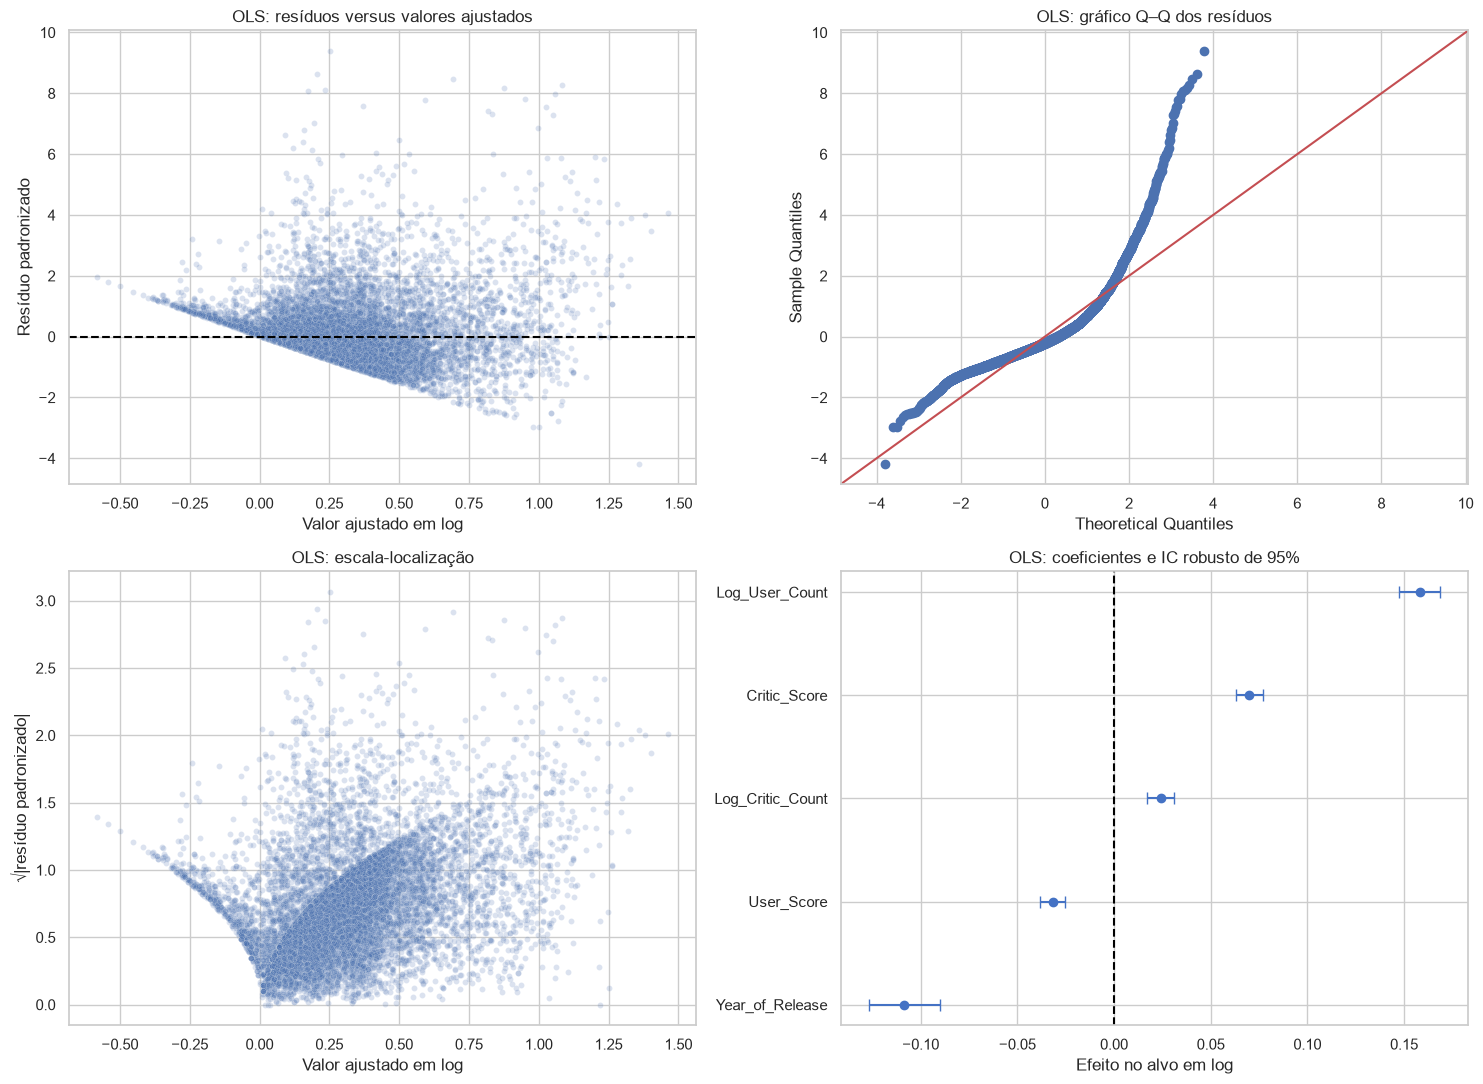

Métricas preditivas do OLS reduzido no teste:


,RMSE,MAE,R2
0,1.943,0.453,0.086


RESUMO_OLS={"r2_ajustado_log": 0.3388, "pvalor_breusch_pagan": 1.5004290928165419e-148, "pvalor_jarque_bera": 0.0, "numero_condicao": 171.8, "rmse_teste": 1.9426, "mae_teste": 0.4528, "r2_teste": 0.0858}


In [26]:
X_ols_teste, _ = preparar_matriz_ols(
    teste, parametros=parametros_ols, colunas_referencia=X_ols_treino.columns
)
previsao_ols = np.clip(np.expm1(modelo_ols.predict(X_ols_teste)), 0, None)
metricas_ols = calcular_metricas(y_teste, previsao_ols)

# Evita a instabilidade do resíduo por influência em uma matriz com muitas dummies.
residuos_ols_padronizados = (modelo_ols.resid - modelo_ols.resid.mean()) / modelo_ols.resid.std()
valores_ajustados_ols = modelo_ols.fittedvalues

fig, eixos = plt.subplots(2, 2, figsize=(15, 11))
sns.scatterplot(x=valores_ajustados_ols, y=residuos_ols_padronizados, alpha=0.2, s=18, ax=eixos[0, 0])
eixos[0, 0].axhline(0, color="black", linestyle="--")
eixos[0, 0].set(title="OLS: resíduos versus valores ajustados", xlabel="Valor ajustado em log", ylabel="Resíduo padronizado")

sm.qqplot(residuos_ols_padronizados, line="45", fit=True, ax=eixos[0, 1])
eixos[0, 1].set_title("OLS: gráfico Q–Q dos resíduos")

sns.scatterplot(
    x=valores_ajustados_ols,
    y=np.sqrt(np.abs(residuos_ols_padronizados)),
    alpha=0.2, s=18, ax=eixos[1, 0],
)
eixos[1, 0].set(title="OLS: escala-localização", xlabel="Valor ajustado em log", ylabel="√|resíduo padronizado|")

coef_numericos = tabela_ols.loc[COLUNAS_OLS_NUMERICAS].sort_values("coeficiente")
erros_inferiores = coef_numericos["coeficiente"] - coef_numericos["IC_2,5%"]
erros_superiores = coef_numericos["IC_97,5%"] - coef_numericos["coeficiente"]
eixos[1, 1].errorbar(
    coef_numericos["coeficiente"], coef_numericos.index,
    xerr=np.vstack([erros_inferiores, erros_superiores]), fmt="o", color="#4472C4", capsize=4,
)
eixos[1, 1].axvline(0, color="black", linestyle="--")
eixos[1, 1].set(title="OLS: coeficientes e IC robusto de 95%", xlabel="Efeito no alvo em log", ylabel="")

plt.tight_layout()
plt.show()

print("Métricas preditivas do OLS reduzido no teste:")
display(pd.DataFrame([metricas_ols]).round(4))

resumo_ols = {
    "r2_ajustado_log": round(float(modelo_ols.rsquared_adj), 4),
    "pvalor_breusch_pagan": float(pvalor_bp),
    "pvalor_jarque_bera": float(pvalor_jb),
    "numero_condicao": round(float(modelo_ols.condition_number), 1),
    "rmse_teste": round(float(metricas_ols["RMSE"]), 4),
    "mae_teste": round(float(metricas_ols["MAE"]), 4),
    "r2_teste": round(float(metricas_ols["R2"]), 4),
}
print("RESUMO_OLS=" + json.dumps(resumo_ols, ensure_ascii=False))

> **Critério de validade:** se os testes rejeitarem homocedasticidade ou normalidade, os erros-padrão convencionais não serão usados. O HC3 torna a inferência mais resistente à heterocedasticidade, mas não transforma associação em causalidade. O desempenho no teste permanece secundário ao Ridge, pois este OLS foi acrescentado como diagnóstico explicativo.

### 5.6 Estabilidade dos coeficientes nas dobras

In [27]:
def extrair_coeficientes(modelo_ajustado):
    # Extrai coeficientes nomeados de um pipeline linear já ajustado.
    pipeline = (
        modelo_ajustado.regressor_
        if isinstance(modelo_ajustado, TransformedTargetRegressor)
        else modelo_ajustado
    )
    if "preprocessamento" not in pipeline.named_steps:
        return pd.Series(dtype=float)
    nomes = pipeline.named_steps["preprocessamento"].get_feature_names_out()
    valores = np.ravel(pipeline.named_steps["regressao"].coef_)
    return pd.Series(valores, index=nomes)


coeficientes_dobras = []
for numero_dobra, (idx_ajuste, _) in enumerate(cv.split(treino), start=1):
    modelo_dobra = clone(modelos[melhor_nome])
    dados_dobra = treino.iloc[idx_ajuste]
    modelo_dobra.fit(dados_dobra[colunas_finais], dados_dobra[ALVO])
    serie = extrair_coeficientes(modelo_dobra).rename(f"dobra_{numero_dobra}")
    coeficientes_dobras.append(serie)

if coeficientes_dobras and not coeficientes_dobras[0].empty:
    estabilidade = pd.concat(coeficientes_dobras, axis=1).fillna(0)
    estabilidade["coef_medio"] = estabilidade.mean(axis=1)
    estabilidade["coef_dp"] = estabilidade.iloc[:, :5].std(axis=1)
    estabilidade["sinal_consistente"] = (
        (estabilidade.iloc[:, :5] >= 0).all(axis=1)
        | (estabilidade.iloc[:, :5] <= 0).all(axis=1)
    )
    estabilidade["magnitude_media"] = estabilidade["coef_medio"].abs()
    display(
        estabilidade.nlargest(15, "magnitude_media")
        [["coef_medio", "coef_dp", "sinal_consistente"]]
    )
else:
    print("O modelo selecionado não oferece coeficientes para análise de estabilidade.")

,coef_medio,coef_dp,sinal_consistente
categoricas__Developer_Nintendo,2.421,0.324,True
categoricas__Publisher_Nintendo,1.256,0.072,True
categoricas__Platform_GB,1.078,0.288,True
categoricas__Platform_NES,0.891,0.222,True
categoricas__Platform_PC,-0.792,0.024,True
categoricas__Developer_Treyarch,0.580,0.215,True
categoricas__Platform_WiiU,-0.488,0.071,True
categoricas__Publisher_Microsoft Game Studios,0.472,0.070,True
numericas__Log_User_Count,0.459,0.010,True
categoricas__Platform_SAT,-0.433,0.026,True


> **Critério:** coeficientes com grande desvio entre dobras ou mudança de sinal não sustentam interpretações fortes. As conclusões de negócio privilegiarão padrões estáveis e métricas agregadas, não um ranking causal de coeficientes.

## 6) Deployment e valor analítico

In [28]:
linha_cv = comparacao_modelos.set_index("modelo").loc[melhor_nome]
linha_teste = metricas_teste.set_index("previsão").loc["limitada a zero"]

resumo_final = {
    "modelo": melhor_nome,
    "rmse_cv": round(float(linha_cv["RMSE_cv"]), 4),
    "rmse_cv_dp": round(float(linha_cv["RMSE_cv_dp"]), 4),
    "mae_cv": round(float(linha_cv["MAE_cv"]), 4),
    "r2_cv": round(float(linha_cv["R2_cv"]), 4),
    "rmse_teste": round(float(linha_teste["RMSE"]), 4),
    "mae_teste": round(float(linha_teste["MAE"]), 4),
    "r2_teste": round(float(linha_teste["R2"]), 4),
    "previsoes_negativas": quantidade_negativas,
    "percentual_negativas": round(float(percentual_negativas), 2),
}

print("RESUMO_FINAL=" + json.dumps(resumo_final, ensure_ascii=False))

RESUMO_FINAL={"modelo": "Ridge — alpha=10", "rmse_cv": 1.2063, "rmse_cv_dp": 0.0623, "mae_cv": 0.497, "r2_cv": 0.2573, "rmse_teste": 1.801, "mae_teste": 0.4936, "r2_teste": 0.2142, "previsoes_negativas": 506, "percentual_negativas": 15.13}


### Uso recomendado

- comparar jogos e segmentos com perfis semelhantes;
- identificar associações entre cobertura, avaliações e desempenho;
- localizar segmentos em que o erro é sistematicamente maior;
- apoiar análises de portfólio, sem substituir pesquisa de mercado.

### Limitações

A base não contém orçamento, investimento em marketing, força prévia da franquia, distribuição, concorrência no lançamento ou qualidade medida de forma independente. Esses fatores ajudam a explicar por que blockbusters permanecem difíceis para uma regressão linear baseada somente nos atributos disponíveis.

### Conclusão

O projeto demonstra de forma auditável quanto a regressão linear consegue explicar, quais otimizações realmente melhoram a validação e onde sua capacidade termina. O valor principal não é apenas a métrica final, mas a conexão entre qualidade dos dados, generalização, resíduos e decisões de negócio.